# ML modelling
Lets answer the question: Can we predict the commercial success of a video game using its characteristics?
The modelling approach is regression, predicting: total_sales(mil)

In this section, machine learning models are developed to predict global video game sales based on game characteristics such as genre, platform, publisher, release timing, and critic score.

Selected Features:
- critic_score
- genre
- console
- publisher
- release_year
- release_month

NOTE: na_sales, jp_sales, pal_sales, other_sales are not included because they are components of total_sales, this would cause data leakage

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor


games = pd.read_csv('C:/Users/ADMIN/Downloads/gamessales_project/dataset/cleaned/cleaned.csv')
games.head(10)

,title,console,genre,publisher,developer,critic_score,total_sales(mil),na_sales(mil),jp_sales(mil),pal_sales(mil),other_sales(mil),release_date,release_year,release_month,sales_sum
0,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.4,20.32,6.37,0.99,9.85,3.12,2013-09-17,2013.0,9.0,20.33
1,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.7,19.39,6.06,0.60,9.71,3.02,2014-11-18,2014.0,11.0,19.39
2,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.6,16.15,8.41,0.47,5.49,1.78,2002-10-28,2002.0,10.0,16.15
3,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,6.8,15.86,9.06,0.06,5.33,1.42,2013-09-17,2013.0,9.0,15.87
4,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.1,15.09,6.18,0.41,6.05,2.44,2015-11-06,2015.0,11.0,15.08
5,Call of Duty: Modern Warfare 3,X360,Shooter,Activision,Infinity Ward,8.7,14.82,9.07,0.13,4.29,1.33,2011-11-08,2011.0,11.0,14.82
6,Call of Duty: Black Ops,X360,Shooter,Activision,Treyarch,8.8,14.74,9.76,0.11,3.73,1.14,2010-11-09,2010.0,11.0,14.74
7,Red Dead Redemption 2,PS4,Action-Adventure,Rockstar Games,Rockstar Games,9.8,13.94,5.26,0.21,6.21,2.26,2018-10-26,2018.0,10.0,13.94
8,Call of Duty: Black Ops II,X360,Shooter,Activision,Treyarch,8.4,13.86,8.27,0.07,4.32,1.20,2012-11-13,2012.0,11.0,13.86
9,Call of Duty: Black Ops II,PS3,Shooter,Activision,Treyarch,8.0,13.80,4.99,0.65,5.88,2.28,2012-11-13,2012.0,11.0,13.80


## Prepare Data for ML

In [7]:
features = [
    'critic_score',
    'genre',
    'console',
    'publisher',
    'release_year'
]

X = games[features]
y = games['total_sales(mil)']

# Encode categorical variables using one-hot encoding
X = pd.get_dummies(X, drop_first=True)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(X.shape, y.shape)

(18922, 797) (18922,)


## Modelling with different models

In [8]:
# Baseline model
model = LinearRegression()
model.fit(X_train, y_train)

pred = model.predict(X_test)
rmse = root_mean_squared_error(y_test, pred)
r2 = r2_score(y_test, pred)

print("RMSE:", rmse)
print("R2:", r2)

RMSE: 0.7573219052584473
R2: 0.2157702853690584


In [9]:
# Random Forest Regressor usually perform better, lets try it out
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rmse = root_mean_squared_error(y_test, rf_pred)
r2 = r2_score(y_test, rf_pred)

print("RMSE:", rmse)
print("R2:", r2)

RMSE: 0.7516493404105247
R2: 0.22747451111425743


In [ ]:
# Now lets try a stronger model, Gradient Boosting Regressor
gb = GradientBoostingRegressor()
gb.fit(X_train, y_train)

gb_pred = gb.predict(X_test)
rmse = root_mean_squared_error(y_test, gb_pred)
r2 = r2_score(y_test, gb_pred)

print("RMSE:", rmse)
print("R2:", r2)

RMSE: 0.7414032025014254
R2: 0.2483923852112978


## Model Performance Comparison

Three regression models were evaluated to predict global video game sales: Linear Regression, Random Forest, and Gradient Boosting. Among the models tested, Gradient Boosting achieved the best performance, producing the lowest RMSE (≈0.74) and the highest R² score (≈0.25). Random Forest performed slightly better than Linear Regression, but the improvement was relatively small.

Overall, the models explain only a moderate portion of the variance in game sales, suggesting that while features such as genre, platform, release year, and critic score provide some predictive power, many other factors likely influence a game's commercial success. These may include marketing efforts, brand recognition, franchise popularity, and external market conditions that are not captured in the dataset.

## Feature Importance 
What drives sales?

In [11]:
importances = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

importances.head(10)

critic_score                0.265438
release_year                0.168657
publisher_Activision        0.061432
genre_Shooter               0.044761
console_PS4                 0.044176
publisher_Rockstar Games    0.039456
console_PS3                 0.030577
console_X360                0.025582
console_PS2                 0.022814
genre_Visual Novel          0.018478
dtype: float64

Text(0.5, 1.0, 'Top Features Influencing Game Sales')

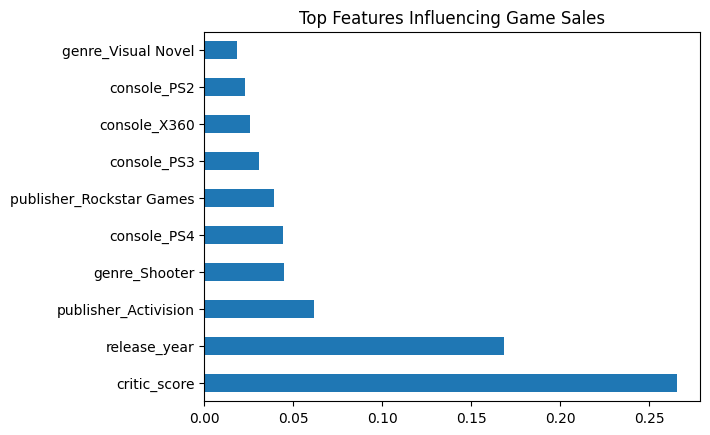

In [12]:
importances.head(10).plot(kind='barh')
plt.title("Top Features Influencing Game Sales")

## Feature Importance Analysis

The feature importance results indicate that critic score is the most influential predictor of game sales, suggesting that higher-rated games tend to perform better commercially. The release year also shows strong importance, reflecting changes in the gaming market over time and the impact of different console generations.

Several platform-related features, such as PlayStation 4, PlayStation 3, Xbox 360, and PlayStation 2, also appear among the important predictors, highlighting the influence of console popularity on sales performance. Additionally, certain publishers and genres contribute to the model’s predictions. For example, publishers like Rockstar Games and Activision show noticeable importance, likely due to the success of major franchises associated with these companies.

Overall, the results suggest that game quality (critic score), market timing (release year), platform choice, and publisher reputation all play meaningful roles in determining commercial success in the video game market.